<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Visión por Computador: de la Convolución a la Detección de Objetos 👁️
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 09
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/09%20-%20Casos%20de%20Estudio%20y%20Aplicaciones/01_Vision_por_Computador.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la **Sección 3.9** del libro (*Computer Vision applications: image classification, object detection*). Una imagen es un **tensor de números**; la visión por computador consiste en **extraer rasgos** de ese tensor y **decidir** qué hay en él (clasificación) y **dónde** está (detección). Seguimos la línea del curso: **implementar desde cero, verificar con `assert` contra `SciPy`/`PyTorch`/`torchvision`** y **reportar con honestidad** lo que funciona y lo que no, con varias semillas.

Al terminar podrás:

1. **Representar** una imagen como tensor `(H, W)` o `(C, H, W)` y explicar la convención `(N, C, H, W)` de PyTorch.
2. **Implementar la convolución 2D** (correlación cruzada) con *padding* y *stride*, **verificarla** contra `scipy.signal.correlate2d` y `torch.nn.functional.conv2d`, y **calcular** el tamaño de la salida y el número de parámetros frente a una capa densa.
3. **Aplicar filtros clásicos** (Sobel, gaussiano, laplaciano), implementar el ***pooling*** y justificar por qué da invarianza **local**.
4. **Clasificar imágenes** con tres enfoques —píxeles, **rasgos clásicos** hechos a mano (histogramas de orientación del gradiente) y **rasgos aprendidos** (una CNN en PyTorch)— y medir con honestidad el efecto del **aumento de datos**.
5. **Definir y calcular desde cero** la **IoU**, la **supresión de no máximos (NMS)**, las **anclas**, la **precisión/recobrado** a un umbral de IoU y el **AP/mAP**.
6. **Construir un detector de juguete** (ventana deslizante + clasificador + NMS) sobre escenas sintéticas, evaluarlo y **reconocer sus límites**, que motivan a **R-CNN, SSD y YOLO**.
7. **Usar** un detector preentrenado de `torchvision` (sección **opcional y protegida**) y enlazar con el *transfer learning* del Módulo 08.

> 📍 **Dónde estamos:** Módulo 09, cuaderno 2 de 4. Venimos del [cuaderno integrador de casos de estudio](00_Casos_de_Estudio_y_Aplicaciones.ipynb). Siguientes: [Procesamiento de lenguaje natural](02_Procesamiento_de_Lenguaje_Natural.ipynb) → [Sistemas de recomendación](03_Sistemas_de_Recomendacion.ipynb).

> 🔗 **Para no repetir:** el perceptrón multicapa, la retropropagación y la integración con PyTorch están en el [Módulo 02, cuaderno 02](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/02_Redes_Neuronales.ipynb); la CNN de aquí **solo cambia la parte de rasgos**. El uso de modelos **preentrenados** (extraer rasgos, *fine-tuning*) se explicó en el [Módulo 08, cuaderno 01](../08%20-%20Temas%20Avanzados%20de%20ML/01_Transfer_Learning_y_Fine_Tuning.ipynb); las métricas de clasificación (precisión, recobrado), en el [Módulo 03](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb); PCA y las *eigenfaces*, en el [Módulo 05](../05%20-%20Reduccion%20de%20Dimensionalidad/00_PCA.ipynb).

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 12 (*Deep Computer Vision Using Convolutional Neural Networks*): *Convolutional Layers*, *Pooling Layers*, *CNN Architectures* (LeNet-5, AlexNet, ResNet), *Using TorchVision's Pretrained Models*, *Classification and Localization*, ***Object Detection*** (*Fully Convolutional Networks*, *You Only Look Once*; IoU y NMS) y *Semantic Segmentation*; Cap. 16 (*Vision and Multimodal Transformers*, *DETR*) (disponible en `Machine Learning/Libros/`; títulos verificados contra el índice del PDF).
- *Machine Learning with Python* — **Tarkeshwar Barua, Kamal Kant Hiran, Ritesh Kumar Jain & Ruchi Doshi** (De Gruyter, 2024). Cap. 8 (*Specialized Applications and Case Studies*), secciones 8.4 (*Computer Vision Applications*) y 8.4.1 (*Object Detection and Segmentation*: SSD, Faster R-CNN, YOLO) (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Machine Learning For Dummies* (2.ª ed.) — **John Paul Mueller & Luca Massaron** (Wiley, 2021). Cap. 17 (*Classifying Images*): *Extracting Visual Features*, *Recognizing Faces Using Eigenfaces*, *Classifying Images* (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Machine Learning Theory and Applications* — **Xavier Vasques** (Wiley, 2024). Cap. 3, sección 3.4.3 (*Convolutional Neural Networks*) (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Python Machine Learning* — **Sebastian Raschka** (Packt, 2015). Cap. 12, apartado *Other neural network architectures* → *Convolutional Neural Networks* (breve; disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- LeCun, Y., Bottou, L., Bengio, Y. & Haffner, P. (1998), *Gradient-based learning applied to document recognition*, **Proceedings of the IEEE** 86(11): 2278–2324 (LeNet-5) · Krizhevsky, A., Sutskever, I. & Hinton, G. E. (2012), *ImageNet classification with deep convolutional neural networks*, **NeurIPS 25** (AlexNet) *(citados de memoria, verificar)*.
- Girshick, R. et al. (2014), *Rich feature hierarchies for accurate object detection and semantic segmentation* (R-CNN), **CVPR** · Ren, S., He, K., Girshick, R. & Sun, J. (2015), *Faster R-CNN*, **NeurIPS 28** · Liu, W. et al. (2016), *SSD: single shot multibox detector*, **ECCV** · Redmon, J., Divvala, S., Girshick, R. & Farhadi, A. (2016), *You only look once: unified, real-time object detection*, **CVPR** *(citados de memoria, verificar)*.
- Everingham, M. et al. (2010), *The PASCAL Visual Object Classes (VOC) challenge*, **IJCV** 88(2): 303–338 (AP y mAP) · Lin, T.-Y. et al. (2014), *Microsoft COCO: common objects in context*, **ECCV** (mAP promediado en varios umbrales de IoU) · Dalal, N. & Triggs, B. (2005), *Histograms of oriented gradients for human detection*, **CVPR** *(citados de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [`scipy.signal.correlate2d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate2d.html) · [`torch.nn.functional.conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.functional.conv2d.html) · [`torchvision.ops.nms`](https://pytorch.org/vision/stable/generated/torchvision.ops.nms.html) · [`torchvision.ops.box_iou`](https://pytorch.org/vision/stable/generated/torchvision.ops.box_iou.html)
- [torchvision: modelos de detección](https://pytorch.org/vision/stable/models.html#object-detection-instance-segmentation-and-person-keypoint-detection) · [scikit-learn: imágenes de ejemplo (`load_sample_image`)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html)

---
## 1. La Imagen como Tensor 🧮

Una **imagen en escala de grises** es una matriz $I\in\mathbb R^{H\times W}$ (cada entrada, la intensidad de un píxel); una **imagen a color** añade un eje de **canales** (rojo, verde, azul): $I\in\mathbb R^{H\times W\times 3}$. NumPy y Matplotlib usan el orden `(H, W, C)`; **PyTorch** usa `(C, H, W)` para una imagen y **`(N, C, H, W)`** para un lote de $N$ imágenes. La **luminancia** (el «gris» percibido) es una combinación lineal de los canales: $Y=0.299\,R+0.587\,G+0.114\,B$.

Un clasificador «ingenuo» **aplana** la imagen en un vector de $H\cdot W$ números y **pierde** la vecindad espacial (el píxel de arriba y el de al lado dejan de ser «vecinos» para un modelo denso). Una **CNN** conserva esa estructura. Usamos dos fuentes **sin descargas**: una fotografía incluida en `scikit-learn` y los **dígitos 8×8** de `load_digits`.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy torch

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy
import sklearn
from scipy import signal
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.datasets import load_digits, load_sample_image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ImportError as e:                                   # este cuaderno REQUIERE PyTorch (en Colab ya viene instalado)
    raise ImportError("Este cuaderno necesita PyTorch: ejecuta  !pip install torch  y reinicia el entorno.") from e

try:                                                       # OPCIONAL: solo para verificar nuestras funciones contra torchvision
    from torchvision.ops import nms as tv_nms, box_iou as tv_box_iou
    HAY_TORCHVISION = True
except Exception:
    HAY_TORCHVISION = False
try:                                                       # OPCIONAL: solo para verificar el filtro de Sobel
    from skimage import filters as sk_filters
    HAY_SKIMAGE = True
except Exception:
    HAY_SKIMAGE = False

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.set_num_threads(2)                                   # redes diminutas: pocos hilos dan tiempos estables
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]

# ---- Banderas del cuaderno ----
RAPIDO = True                      # True: 3 semillas y 15 epocas (~1 min en total). False: 8 semillas y 40 epocas (~4 min)
USAR_DETECTOR_PRETRAINED = False   # True SOLO con red (Colab): descarga un detector de torchvision en la seccion 8 (opcional)
SEMILLAS = list(range(3 if RAPIDO else 8))
EPOCAS_CNN = 15 if RAPIDO else 40
print(f"Entorno listo | numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__} | torch {torch.__version__}")
print(f"torchvision disponible: {HAY_TORCHVISION} | scikit-image disponible: {HAY_SKIMAGE}")
print(f"RAPIDO = {RAPIDO} | semillas = {len(SEMILLAS)} | épocas de la CNN = {EPOCAS_CNN}")

In [ ]:
# ============================================================
# 1. La imagen como tensor
# ============================================================
foto = load_sample_image("china.jpg")                      # imagen en color incluida con scikit-learn (sin descargas)
print("Foto en color:", foto.shape, foto.dtype, f"| rango [{foto.min()}, {foto.max()}]  -> (alto, ancho, canales)")
gris = (foto.astype(np.float64) / 255.0) @ np.array([0.299, 0.587, 0.114])      # luminancia: combinacion ponderada de R, G, B
print("En grises:", gris.shape, gris.dtype, f"| rango [{gris.min():.2f}, {gris.max():.2f}]")

digitos = load_digits()
img8 = digitos.images[3]
print("Un dígito de scikit-learn:", img8.shape, "| valores enteros 0-16")

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
axes[0].imshow(foto); axes[0].set_title(f"Color {foto.shape}", fontsize=9)
for c, (nombre, cmap) in enumerate([("Canal R", "Reds"), ("Canal G", "Greens"), ("Canal B", "Blues")]):
    axes[c + 1].imshow(foto[:, :, c], cmap=cmap); axes[c + 1].set_title(nombre, fontsize=9)
axes[4].imshow(gris, cmap="gray"); axes[4].set_title("Luminancia (1 canal)", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

# Una imagen ES una matriz de numeros: ampliamos un parche de 8x8 pixeles y mostramos los valores
parche = gris[200:208, 300:308]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].imshow(img8, cmap="gray_r"); axes[0].set_title("Dígito 8×8 (valores 0–16)", fontsize=9)
axes[1].imshow(parche, cmap="gray"); axes[1].set_title("Parche 8×8 de la foto (luminancia 0–1)", fontsize=9)
for i in range(8):
    for j in range(8):
        axes[0].text(j, i, int(img8[i, j]), ha="center", va="center", fontsize=7, color="white" if img8[i, j] > 8 else "black")
        axes[1].text(j, i, f"{parche[i, j]:.2f}", ha="center", va="center", fontsize=6, color="white" if parche[i, j] < 0.5 else "black")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# El tensor de un LOTE de imagenes en PyTorch es (N, C, H, W): lote, canales, alto, ancho
lote = torch.as_tensor(foto.transpose(2, 0, 1)[None].astype(np.float32) / 255.0)
print("Convención de PyTorch (N, C, H, W):", tuple(lote.shape), "| NumPy/Matplotlib usan (H, W, C):", foto.shape)
assert lote.shape == (1, 3, foto.shape[0], foto.shape[1]) and gris.ndim == 2

---
##### 🛠️ Práctica 1: Del color al gris con tensores de PyTorch

La Sección 1 calculó la luminancia con NumPy (`foto` en orden `(H, W, C)`). Hazlo ahora con PyTorch, que usa `(N, C, H, W)`, partiendo de `lote` (la foto como tensor de forma `(1, 3, H, W)` con valores en $[0,1]$) y de `gris` (la luminancia ya calculada con NumPy):

1. Crea `pesos_lum`, un tensor con `[0.299, 0.587, 0.114]` y forma `(1, 3, 1, 1)` (así se multiplica canal a canal con `lote`).
2. Calcula `gris_t` multiplicando `lote * pesos_lum` y sumando a lo largo del eje de canales (`dim=1`, conservando ese eje con `keepdim=True`).
3. Calcula `medias_canal`, la media de cada canal de `lote` (promedia sobre `dim=(0, 2, 3)`), y guarda en `canal_dominante` la letra (`"R"`, `"G"` o `"B"`) del canal con mayor media.
4. Verifica con `assert` que `gris_t` tiene forma `(1, 1, H, W)` y coincide con `gris`, y que `medias_canal` coincide con `foto.mean(axis=(0, 1)) / 255`.

In [ ]:
# Escribe tu código aquí

# pesos_lum = torch.tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)
# gris_t = (lote * ...).sum(dim=1, keepdim=True)
# medias_canal = lote.mean(dim=(0, 2, 3))
# canal_dominante = "RGB"[int(medias_canal.argmax())]


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
pesos_lum = torch.tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)         # un peso por canal; los ejes de tamaño 1 se "estiran" (broadcasting)
gris_t = (lote * pesos_lum).sum(dim=1, keepdim=True)                     # combinación lineal de R, G y B -> un solo canal

medias_canal = lote.mean(dim=(0, 2, 3))                                  # brillo medio de R, G y B
canal_dominante = "RGB"[int(medias_canal.argmax())]
print("Medias por canal (R, G, B):", np.round(medias_canal.numpy(), 3), "| canal dominante:", canal_dominante)

assert gris_t.shape == (1, 1, foto.shape[0], foto.shape[1])
assert np.allclose(gris_t[0, 0].numpy(), gris, atol=1e-5)
assert np.allclose(medias_canal.numpy(), foto.mean(axis=(0, 1)) / 255, atol=1e-5)
print("La luminancia con PyTorch coincide con la de NumPy: es la misma combinación lineal de canales, solo cambia la convención de ejes.")
```
</details>

---


---
## 2. La Convolución desde Cero 🔍

Lo que las bibliotecas llaman «convolución» en una CNN es, en rigor, una **correlación cruzada**: se **desliza** un pequeño **kernel** $K\in\mathbb R^{k_h\times k_w}$ sobre la imagen y, en cada posición, se **suma el producto elemento a elemento** con la ventana que cubre:

$$(I\star K)[i,j]=\sum_{u=0}^{k_h-1}\sum_{v=0}^{k_w-1} I[i\,s+u,\;j\,s+v]\;K[u,v],$$

donde $s$ es el ***stride*** (paso). La **convolución matemática** es lo mismo con el kernel **volteado** (lo verificaremos); en una red da igual porque los pesos se **aprenden**. Con ***padding*** de $p$ ceros alrededor y una dimensión de entrada $n$, la salida mide

$$n_{\text{sal}}=\Big\lfloor\frac{n+2p-k}{s}\Big\rfloor+1 .$$

Para una entrada con $C$ canales y $F$ filtros, cada filtro es un tensor $C\times k_h\times k_w$ que se suma **a través de los canales** y produce un **mapa de rasgos**; la capa tiene $F\,(C\,k_h k_w+1)$ parámetros (incluyendo un sesgo por filtro). Tres propiedades explican su éxito en imágenes:

| Propiedad | Qué significa | Consecuencia |
|---|---|---|
| **Conectividad local** | Cada salida depende solo de una ventana $k_h\times k_w$ | Pocos parámetros; capta patrones locales (bordes, texturas) |
| **Pesos compartidos** | El **mismo** kernel se usa en toda la imagen | Parámetros **independientes del tamaño** de la imagen |
| **Equivarianza a la traslación** | Desplazar la imagen **desplaza** el mapa de rasgos: $(T_\delta I)\star K=T_\delta(I\star K)$ | Un patrón se detecta **donde** esté |

Nótese: **equivarianza** (el mapa se desplaza con la imagen) **no es** **invarianza** (la salida final no cambia). La invarianza —parcial— la aportan el *pooling* y, sobre todo, **los datos** (aumento), como veremos.

In [ ]:
# ============================================================
# 2. Convolucion (correlacion cruzada) desde cero
# ============================================================
def correlacion2d_bucles(img, k, padding=0, stride=1):
    """Version didactica con bucles: desliza el kernel y suma el producto elemento a elemento."""
    if padding:
        img = np.pad(img, padding)                             # ceros alrededor
    kh, kw = k.shape
    ho, wo = (img.shape[0] - kh) // stride + 1, (img.shape[1] - kw) // stride + 1
    salida = np.zeros((ho, wo))
    for i in range(ho):
        for j in range(wo):
            salida[i, j] = np.sum(img[i * stride:i * stride + kh, j * stride:j * stride + kw] * k)
    return salida


def conv2d_np(x, w, b=None, padding=0, stride=1):
    """Capa convolucional vectorizada (como torch.nn.functional.conv2d): x (N,C,H,W), w (F,C,kh,kw), b (F,) -> (N,F,Ho,Wo)."""
    if padding:
        x = np.pad(x, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    ventanas = sliding_window_view(x, w.shape[2:], axis=(2, 3))[:, :, ::stride, ::stride]      # (N, C, Ho, Wo, kh, kw)
    salida = np.einsum("ncijkl,fckl->nfij", ventanas, w)
    return salida if b is None else salida + b[None, :, None, None]


def tam_salida(n, k, p=0, s=1):
    return (n + 2 * p - k) // s + 1

rng = np.random.default_rng(0)
# --- (a) Verificacion contra scipy.signal.correlate2d (modos 'valid', 'same' y 'full') ---
img = rng.normal(size=(12, 15)); k = rng.normal(size=(3, 3))
assert np.allclose(correlacion2d_bucles(img, k), signal.correlate2d(img, k, mode="valid"))
assert np.allclose(correlacion2d_bucles(img, k, padding=1), signal.correlate2d(img, k, mode="same"))
assert np.allclose(correlacion2d_bucles(img, k, padding=2), signal.correlate2d(img, k, mode="full"))
assert np.allclose(conv2d_np(img[None, None], k[None, None])[0, 0], signal.correlate2d(img, k, mode="valid"))
# la CONVOLUCION matematica es la correlacion con el kernel volteado
assert np.allclose(signal.convolve2d(img, k, mode="valid"), signal.correlate2d(img, k[::-1, ::-1], mode="valid"))
print("OK: correlación 2D (bucles y vectorizada) == scipy.signal.correlate2d en 'valid', 'same' y 'full'; convolución == correlación con kernel volteado.")

# --- (b) Verificacion contra torch.nn.functional.conv2d (varios canales, relleno y paso) ---
for (p, s) in [(0, 1), (1, 1), (2, 2), (1, 3)]:
    x = rng.normal(size=(2, 3, 11, 13)); w = rng.normal(size=(4, 3, 3, 5)); b = rng.normal(size=4)
    mio = conv2d_np(x, w, b, padding=p, stride=s)
    ref = F.conv2d(torch.as_tensor(x), torch.as_tensor(w), torch.as_tensor(b), padding=p, stride=s).numpy()
    assert mio.shape == ref.shape and np.allclose(mio, ref), (p, s)
    assert mio.shape[2:] == (tam_salida(11, 3, p, s), tam_salida(13, 5, p, s))              # la formula del tamano de salida
print("OK: conv2d_np == torch.nn.functional.conv2d (kernel 3×5, 3 canales → 4 filtros, padding/stride varios) y tamaño = ⌊(n+2p−k)/s⌋+1.")

# --- (c) Equivarianza a la traslacion: desplazar la imagen y luego convolucionar == convolucionar y luego desplazar ---
ima = rng.normal(size=(20, 20)); desp = np.roll(ima, shift=(2, 3), axis=(0, 1))
a = correlacion2d_bucles(desp, k, padding=1); bb = np.roll(correlacion2d_bucles(ima, k, padding=1), shift=(2, 3), axis=(0, 1))
assert np.allclose(a[5:-5, 5:-5], bb[5:-5, 5:-5])                                           # igual en el interior (los bordes dependen del relleno)
print("OK: equivarianza a la traslación (en el interior): conv(desplazar(I)) == desplazar(conv(I)).")

# --- (d) Costo: bucles vs vectorizado, y parametros de una capa convolucional vs una densa ---
t0 = time.time(); r1 = correlacion2d_bucles(gris, np.ones((3, 3)) / 9, padding=1); t_bucles = time.time() - t0
t0 = time.time(); r2 = conv2d_np(gris[None, None], np.ones((1, 1, 3, 3)) / 9, padding=1)[0, 0]; t_vec = time.time() - t0
assert np.allclose(r1, r2)
print(f"Suavizado 3×3 de la foto {gris.shape}: bucles {t_bucles:.2f} s | vectorizado {t_vec * 1000:.1f} ms (mismo resultado).")
C, H, W, Fm, kk = 3, 64, 64, 16, 3
print(f"Parámetros para 16 mapas sobre una imagen 3×64×64: capa convolucional 3×3 = {Fm * C * kk * kk + Fm:,} | capa densa equivalente = {(C * H * W) * (Fm * H * W):,}")

---
**Lectura.** Las tres implementaciones **coinciden numéricamente**: los bucles didácticos, la versión vectorizada con `sliding_window_view` y las de `SciPy` y `PyTorch` (con varios canales, *padding* y *stride*, y un kernel no cuadrado 3×5). La versión vectorizada es **cientos de veces más rápida** que los bucles; por eso las bibliotecas no hacen bucles en Python. Y la comparación de parámetros muestra por qué se usan convoluciones: una capa convolucional 3×3 con 16 filtros tiene **448 parámetros**, mientras que la capa **densa** equivalente (cada salida conectada con cada entrada) tendría **más de 800 millones**.

---

## 3. Filtros Clásicos y *Pooling* 🖼️

Antes de las CNN, los **kernels se diseñaban a mano**. Con nuestra convolución podemos reproducir los clásicos:

- **Sobel** ($G_x$, $G_y$): aproxima la **derivada** de la intensidad en horizontal y en vertical; $\|\nabla I\|=\sqrt{G_x^2+G_y^2}$ mide la **fuerza del borde** y $\theta=\operatorname{atan2}(G_y,G_x)$ su **orientación**.
- **Gaussiano**: promedio ponderado que **suaviza** y atenúa el ruido.
- **Laplaciano**: segunda derivada; responde a **cambios bruscos** en cualquier dirección (se aplica tras suavizar, para no amplificar el ruido).

El ***pooling*** (agrupamiento) reduce cada bloque $m\times m$ del mapa a **un** número: el **máximo** (*max-pooling*) o el **promedio**. Reduce el tamaño (y el cómputo posterior) y vuelve la representación **tolerante a pequeños desplazamientos**: si el borde se mueve un píxel dentro del bloque, el máximo casi no cambia. Es **invarianza local**, no global.

In [ ]:
# ============================================================
# 3. Filtros clasicos de bordes y pooling
# ============================================================
SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)         # derivada horizontal (detecta bordes verticales)
SOBEL_Y = SOBEL_X.T                                                              # derivada vertical (detecta bordes horizontales)
GAUSS = np.array([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]], dtype=float) / 256
LAPLACE = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=float)

def filtrar(img, k):
    return conv2d_np(img[None, None], k[None, None], padding=k.shape[0] // 2)[0, 0]

gx, gy = filtrar(gris, SOBEL_X), filtrar(gris, SOBEL_Y)
magnitud = np.hypot(gx, gy)
suave = filtrar(gris, GAUSS)
lap = filtrar(suave, LAPLACE)                                                    # "laplaciano de gaussiana": primero suavizar, luego bordes

fig, axes = plt.subplots(2, 3, figsize=(15, 7.2))
for ax, im, t, cm in [(axes[0, 0], gris, "Original (grises)", "gray"), (axes[0, 1], gx, "Sobel X (bordes verticales)", "RdBu_r"),
                      (axes[0, 2], gy, "Sobel Y (bordes horizontales)", "RdBu_r"), (axes[1, 0], suave, "Gaussiano 5×5 (suavizado)", "gray"),
                      (axes[1, 1], magnitud, "Magnitud del gradiente √(Gx²+Gy²)", "magma"), (axes[1, 2], lap, "Laplaciano del suavizado", "RdBu_r")]:
    v = np.abs(im).max() if cm == "RdBu_r" else None
    ax.imshow(im, cmap=cm, vmin=-v if v else None, vmax=v); ax.set_title(t, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

# Verificacion opcional contra scikit-image: su Sobel es nuestra magnitud con otra normalizacion
if HAY_SKIMAGE:
    ref = sk_filters.sobel(gris)
    r = np.corrcoef(magnitud[2:-2, 2:-2].ravel(), ref[2:-2, 2:-2].ravel())[0, 1]
    assert r > 0.999
    print(f"scikit-image disponible: correlación entre nuestra magnitud de Sobel y skimage.filters.sobel = {r:.5f} (difieren solo en la escala).")
else:
    print("scikit-image no está instalado: se omite la verificación opcional del filtro de Sobel (el resto no depende de ella).")

# Un borde vertical sintetico: la respuesta de Sobel X se concentra justo en el borde
escalon = np.zeros((9, 12)); escalon[:, 6:] = 1.0
resp = correlacion2d_bucles(escalon, SOBEL_X, padding=1)
assert resp[4, 5] > 0 and resp[4, 6] > 0 and abs(resp[4, 2]) < 1e-12 and abs(resp[4, 10]) < 1e-12
print("Borde vertical sintético: respuesta de Sobel X en las columnas 5-6 =", resp[4, 5:7], "| lejos del borde = 0")

# --- Pooling desde cero y verificacion contra PyTorch ---
def pool2d_np(x, tam=2, modo="max"):
    """Pooling no solapado sobre (H, W): reduce cada bloque tam×tam a un numero (max o promedio)."""
    h, w = (x.shape[0] // tam) * tam, (x.shape[1] // tam) * tam
    bloques = x[:h, :w].reshape(h // tam, tam, w // tam, tam)
    return bloques.max(axis=(1, 3)) if modo == "max" else bloques.mean(axis=(1, 3))

z = rng.normal(size=(10, 14))
assert np.allclose(pool2d_np(z, 2, "max"), F.max_pool2d(torch.as_tensor(z)[None, None], 2).numpy()[0, 0])
assert np.allclose(pool2d_np(z, 2, "mean"), F.avg_pool2d(torch.as_tensor(z)[None, None], 2).numpy()[0, 0])
print("OK: pool2d_np (max y promedio) == torch.nn.functional.max_pool2d / avg_pool2d.")

# Pooling = invariancia LOCAL: desplazar la imagen 1 pixel cambia menos los mapas ya reducidos que los originales
desplazada = np.roll(gris, 1, axis=1)
m1, m2 = np.hypot(filtrar(gris, SOBEL_X), filtrar(gris, SOBEL_Y)), np.hypot(filtrar(desplazada, SOBEL_X), filtrar(desplazada, SOBEL_Y))
r_sin = np.corrcoef(m1.ravel(), m2.ravel())[0, 1]
r_con = np.corrcoef(pool2d_np(m1, 4, "max").ravel(), pool2d_np(m2, 4, "max").ravel())[0, 1]
print(f"Correlación entre el mapa de bordes de la foto y el de la foto desplazada 1 píxel: sin pooling {r_sin:.3f} | con max-pooling 4×4 {r_con:.3f}")
print(f"El pooling reduce el mapa de {m1.shape} a {pool2d_np(m1, 4).shape} (16 veces menos valores) y lo hace más tolerante a pequeños desplazamientos.")
assert r_con > r_sin

---
**Lectura.** Sobel X responde a los bordes **verticales** y Sobel Y a los **horizontales** (la magnitud los combina); el gaussiano suaviza y el laplaciano del suavizado marca contornos finos. En el borde sintético, la respuesta se concentra **justo en la transición** y es cero lejos de ella. El *max-pooling* no solo reduce el mapa 16 veces: al desplazar la foto **un solo píxel**, la correlación entre los mapas de bordes sube de ≈ 0.77 (sin *pooling*) a ≈ 0.98 (con *pooling* 4×4). Eso es la invarianza **local** del *pooling* en acción.

---

## 4. Clasificación de Imágenes: Rasgos Clásicos frente a Rasgos Aprendidos 🔢

**Tres enfoques** para clasificar los 1 797 dígitos 8×8 de `load_digits` (10 clases):

1. **Píxeles crudos** → regresión logística ([Módulo 01](../01%20-%20Modelos%20Lineales%20Supervisados/02_Regresion_Logistica.ipynb)) o MLP ([Módulo 02](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/02_Redes_Neuronales.ipynb)). No explotan la estructura espacial.
2. **Rasgos clásicos** (*hand-crafted*): un humano **diseña** los rasgos. Implementamos una versión mínima de **HOG** (Dalal y Triggs, 2005): con Sobel se calculan magnitud y orientación del gradiente y, por celda, un **histograma de orientaciones** ponderado por la magnitud. Es robusto a cambios de iluminación, pero el diseño es **manual**.
3. **Rasgos aprendidos**: una **CNN** aprende los kernels **por descenso del gradiente**, junto con el clasificador. La arquitectura: `conv(1→8) → ReLU → conv(8→16) → ReLU → max-pool → densa(256→10)`; solo cambia la parte de rasgos respecto al MLP del Módulo 02.

**El aumento de datos** (*data augmentation*) fabrica ejemplos nuevos aplicando transformaciones que **no cambian la etiqueta** (aquí, trasladar ≤ 1 píxel). Lo evaluamos con **dos pruebas**: la **normal** y una **desplazada** (cada imagen movida hasta 1 píxel), y con **dos tamaños de entrenamiento** (completo y 100 imágenes). Reportamos **media ± desviación entre semillas**; con tan pocas semillas la desviación es una **guía**, no un intervalo de confianza.

In [ ]:
# ============================================================
# 4. Clasificacion de imagenes (digitos 8x8): rasgos clasicos vs. aprendidos vs. CNN
# ============================================================
X_all = (digitos.data / 16.0).astype(np.float32).reshape(-1, 8, 8)               # (1797, 8, 8) en [0, 1]
y_all = digitos.target
Xtr_full, Xte, ytr_full, yte = train_test_split(X_all, y_all, test_size=0.25, stratify=y_all, random_state=0)
print(f"Entrenamiento {Xtr_full.shape} | prueba {Xte.shape} (10 clases, ≈ 10 % cada una)")


def desplazar(X, rng):
    """Aumento de datos: traslada cada imagen (N,8,8) un pixel al azar en x e y (dx, dy en {-1,0,1}); lo que sale se pierde, lo que entra es 0."""
    Xp = np.pad(X, ((0, 0), (1, 1), (1, 1)))
    dx, dy = rng.integers(-1, 2, len(X)), rng.integers(-1, 2, len(X))
    out = np.empty_like(X)
    for i in range(len(X)):
        out[i] = Xp[i, 1 + dy[i]:9 + dy[i], 1 + dx[i]:9 + dx[i]]
    return out


def hog_lite(X, bins=8, celda=4):
    """Rasgos CLASICOS hechos a mano: histogramas de orientacion del gradiente (idea de HOG) con nuestra convolucion.
    Sobel -> magnitud y angulo (sin signo) -> por cada celda celda×celda, histograma de angulos ponderado por la magnitud."""
    gx = conv2d_np(X[:, None], SOBEL_X[None, None], padding=1)[:, 0]
    gy = conv2d_np(X[:, None], SOBEL_Y[None, None], padding=1)[:, 0]
    mag, ang = np.hypot(gx, gy), np.mod(np.arctan2(gy, gx), np.pi)
    idx = np.minimum((ang / np.pi * bins).astype(int), bins - 1)
    n, h, w = X.shape
    feats = np.zeros((n, h // celda, w // celda, bins))
    for ci in range(h // celda):
        for cj in range(w // celda):
            m = mag[:, ci * celda:(ci + 1) * celda, cj * celda:(cj + 1) * celda].reshape(n, -1)
            b = idx[:, ci * celda:(ci + 1) * celda, cj * celda:(cj + 1) * celda].reshape(n, -1)
            for k in range(bins):
                feats[:, ci, cj, k] = (m * (b == k)).sum(1)
    return feats.reshape(n, -1)


class CNNPequena(nn.Module):
    """conv(1→8)+ReLU → conv(8→16)+ReLU → max-pool 2 → densa(256→10). Construye sobre el MLP del Módulo 02: cambia la primera parte."""
    def __init__(self):
        super().__init__()
        self.rasgos = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Flatten())
        self.clasificador = nn.Linear(16 * 4 * 4, 10)

    def forward(self, x):
        return self.clasificador(self.rasgos(x))


def entrenar_cnn(Xtr, ytr, semilla, aumentar=False, epocas=EPOCAS_CNN, lote=64):
    torch.manual_seed(semilla); rng = np.random.default_rng(semilla)
    red = CNNPequena(); opt = torch.optim.Adam(red.parameters(), lr=3e-3)
    y = torch.as_tensor(ytr)
    for _ in range(epocas):
        Xe = desplazar(Xtr, rng) if aumentar else Xtr                           # una version trasladada distinta en CADA epoca
        X = torch.as_tensor(Xe[:, None]); orden = torch.randperm(len(X))
        red.train()
        for i in range(0, len(X), lote):
            idx = orden[i:i + lote]
            opt.zero_grad(); F.cross_entropy(red(X[idx]), y[idx]).backward(); opt.step()
    return red


def acc_cnn(red, X, y):
    red.eval()
    with torch.no_grad():
        return float((red(torch.as_tensor(X[:, None])).argmax(1).numpy() == y).mean())


# --- Conteo de parametros: la CNN comparte pesos ---
n_cnn = sum(p.numel() for p in CNNPequena().parameters())
n_mlp = 64 * 64 + 64 + 64 * 10 + 10
print(f"Parámetros: regresión logística {64 * 10 + 10} | MLP 64-64-10 {n_mlp} | CNN pequeña {n_cnn}")

# --- Protocolo: varias semillas; dos escenarios de ENTRENAMIENTO (completo y 100 imagenes) y dos de PRUEBA (normal y desplazada) ---
t0 = time.time()
rng_prueba = np.random.default_rng(123)
Xte_desp = desplazar(Xte, rng_prueba)                                           # prueba "mas dificil": cada imagen movida hasta 1 pixel
filas = []
for n_ent in [len(Xtr_full), 100]:
    for s in SEMILLAS:
        if n_ent < len(Xtr_full):
            Xtr, _, ytr, _ = train_test_split(Xtr_full, ytr_full, train_size=n_ent, stratify=ytr_full, random_state=s)
        else:
            Xtr, ytr = Xtr_full, ytr_full
        rng_a = np.random.default_rng(1000 + s)
        Xa = np.concatenate([Xtr] + [desplazar(Xtr, rng_a) for _ in range(2)]); ya = np.tile(ytr, 3)       # 3x datos: original + 2 trasladadas
        modelos = {}
        modelos["Reg. logística (píxeles)"] = LogisticRegression(max_iter=1000).fit(Xtr.reshape(len(Xtr), -1), ytr)
        modelos["Reg. logística + aumento"] = LogisticRegression(max_iter=300, tol=1e-3).fit(Xa.reshape(len(Xa), -1), ya)
        modelos["MLP (píxeles)"] = MLPClassifier((64,), max_iter=400, random_state=s).fit(Xtr.reshape(len(Xtr), -1), ytr)
        modelos["Rasgos HOG-lite + reg. logística"] = LogisticRegression(max_iter=1000).fit(hog_lite(Xtr), ytr)
        res = {}
        for nombre, m in modelos.items():
            if "HOG" in nombre:
                res[nombre] = (m.score(hog_lite(Xte), yte), m.score(hog_lite(Xte_desp), yte))
            else:
                res[nombre] = (m.score(Xte.reshape(len(Xte), -1), yte), m.score(Xte_desp.reshape(len(Xte_desp), -1), yte))
        cnn = entrenar_cnn(Xtr, ytr, s); cnn_a = entrenar_cnn(Xtr, ytr, s, aumentar=True)
        res["CNN pequeña"] = (acc_cnn(cnn, Xte, yte), acc_cnn(cnn, Xte_desp, yte))
        res["CNN pequeña + aumento"] = (acc_cnn(cnn_a, Xte, yte), acc_cnn(cnn_a, Xte_desp, yte))
        for nombre, (a1, a2) in res.items():
            filas.append({"n_ent": n_ent, "semilla": s, "modelo": nombre, "prueba normal": a1, "prueba desplazada": a2})
df4 = pd.DataFrame(filas)
orden_m = ["Reg. logística (píxeles)", "Reg. logística + aumento", "MLP (píxeles)", "Rasgos HOG-lite + reg. logística", "CNN pequeña", "CNN pequeña + aumento"]
for n_ent in [len(Xtr_full), 100]:
    sub = df4[df4.n_ent == n_ent].groupby("modelo")[["prueba normal", "prueba desplazada"]].agg(["mean", "std"])
    tabla = pd.DataFrame({c: sub[c]["mean"].map("{:.3f}".format) + " ± " + sub[c]["std"].fillna(0).map("{:.3f}".format) for c in ["prueba normal", "prueba desplazada"]}).loc[orden_m]
    print(f"\n--- Exactitud con {n_ent} imágenes de entrenamiento (media ± desv. de {len(SEMILLAS)} semillas) ---")
    display(tabla)
print(f"[{time.time() - t0:.0f} s]")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
for ax, n_ent in zip(axes, [len(Xtr_full), 100]):
    sub = df4[df4.n_ent == n_ent].groupby("modelo")[["prueba normal", "prueba desplazada"]].mean().loc[orden_m]
    x = np.arange(len(orden_m)); ancho = 0.38
    ax.bar(x - ancho / 2, sub["prueba normal"], ancho, color=PALETA[0], label="Prueba normal")
    ax.bar(x + ancho / 2, sub["prueba desplazada"], ancho, color=PALETA[1], label="Prueba desplazada ≤ 1 píxel")
    ax.set_xticks(x); ax.set_xticklabels([m.replace(" (", "\n(").replace(" + ", "\n+ ") for m in orden_m], fontsize=7)
    ax.set_ylim(0.3, 1.0); ax.set_ylabel("Exactitud (media de semillas)"); ax.legend(fontsize=8)
    ax.set_title(f"{n_ent} imágenes de entrenamiento", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

# --- Que cambia con el desplazamiento y que aprendieron los filtros de la primera capa ---
fig, axes = plt.subplots(3, 8, figsize=(14, 5.6))
for j in range(4):
    axes[0, j].imshow(Xte[j], cmap="gray_r"); axes[0, j].set_title(f"original ({yte[j]})", fontsize=8)
    axes[0, j + 4].imshow(Xte_desp[j], cmap="gray_r"); axes[0, j + 4].set_title("desplazada", fontsize=8)
filtros = cnn_a.rasgos[0].weight.detach().numpy()[:, 0]                         # los 8 filtros 3x3 de la CNN con aumento
filtros_na = cnn.rasgos[0].weight.detach().numpy()[:, 0]
for j in range(8):
    v = np.abs(filtros[j]).max(); axes[1, j].imshow(filtros[j], cmap="RdBu_r", vmin=-v, vmax=v)
    v = np.abs(filtros_na[j]).max(); axes[2, j].imshow(filtros_na[j], cmap="RdBu_r", vmin=-v, vmax=v)
axes[1, 0].set_ylabel("filtros\n(con aumento)", fontsize=8); axes[2, 0].set_ylabel("filtros\n(sin aumento)", fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Arriba: desplazar ≤ 1 píxel una imagen 8×8 ya cambia mucho el vector de píxeles · Abajo: los 8 filtros 3×3 aprendidos por la primera capa", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

def media_de(modelo, col, n=len(Xtr_full)):
    return df4[(df4.n_ent == n) & (df4.modelo == modelo)][col].mean()
assert media_de("CNN pequeña + aumento", "prueba desplazada") > media_de("CNN pequeña", "prueba desplazada") + 0.2       # el aumento hace a la CNN robusta al desplazamiento
assert media_de("CNN pequeña + aumento", "prueba desplazada") > media_de("Reg. logística + aumento", "prueba desplazada") + 0.1
assert media_de("Reg. logística (píxeles)", "prueba normal") > 0.9 and media_de("CNN pequeña", "prueba normal") > 0.95

---
**Lectura honesta de la clasificación.** (1) En la **prueba normal**, todos los modelos de píxeles y la CNN rondan **0.97**: con dígitos de 8×8 **limpios y centrados**, la CNN **no es claramente mejor** que una regresión logística o un MLP (la diferencia es de décimas de punto, comparable a la desviación entre semillas). (2) Los **rasgos HOG-lite** quedan **por debajo** (≈ 0.91): con celdas de 4×4 sobre 8×8 píxeles hay muy poca información espacial; el diseño manual no es gratis. (3) En la **prueba desplazada** todo se **desploma** (≈ 0.33–0.51): desplazar 1 píxel una imagen de 8×8 cambia mucho el vector de píxeles; **la CNN sin aumento tampoco es invariante** (≈ 0.45), porque la capa densa final sí depende de la **posición** de cada rasgo. (4) La **CNN con aumento** es la única que **sobrevive** (≈ 0.92), sin perder nada en la prueba normal; la regresión logística con aumento mejora (≈ 0.58) pero **paga** en la normal (≈ 0.93), pues un modelo lineal no tiene capacidad para ser invariante. (5) Con **100 imágenes**, el aumento **perjudica** en la prueba normal (la CNN pasa de ≈ 0.85 a ≈ 0.74): con tan pocos datos y el mismo presupuesto de épocas, el modelo no alcanza a aprender tanto las formas como la invarianza. **Conclusión:** el aumento no es magia; ayuda cuando la **invarianza que enseña es la que necesitará el modelo en producción** y hay capacidad y datos suficientes. Los filtros dibujados son pequeños y ruidosos; con 8×8 píxeles no esperes detectores de bordes tan limpios como en una red grande.

---

## 5. Detección de Objetos: Cajas, IoU, NMS y Anclas 📦

**Clasificar** responde «¿qué hay?»; **detectar** responde «¿qué hay y **dónde**?»: para cada objeto, una **caja delimitadora** (*bounding box*) $[x_1,y_1,x_2,y_2]$, una **clase** y un **puntaje**. Las piezas básicas:

**Intersección sobre unión (IoU)**, el criterio estándar de «qué tanto se parecen dos cajas»:
$$\operatorname{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}\in[0,1].$$
Una detección se considera **acierto** si su IoU con una caja real es $\ge$ un umbral (típicamente 0.5).

**Supresión de no máximos (NMS)**. Un detector produce **muchas cajas casi iguales** alrededor de cada objeto. NMS conserva la de mayor puntaje y **elimina** las que se solapan con ella más que un umbral $\tau$ (IoU $>\tau$); repite con la siguiente de mayor puntaje. Es *greedy* y dependiente de $\tau$: un $\tau$ bajo **fusiona objetos distintos** pegados; uno alto **deja duplicados**.

**Anclas** (*anchor boxes*, Faster R-CNN, SSD, YOLOv2+): en cada posición de una cuadrícula se fijan cajas de referencia de varias **escalas** y **proporciones**; el detector no predice cajas «de la nada» sino **correcciones** de las anclas (típicamente $t_x=(x-x_a)/w_a$, $t_y=(y-y_a)/h_a$, $t_w=\ln(w/w_a)$, $t_h=\ln(h/h_a)$) y una clase por ancla. Una ancla es **positiva** si su IoU con un objeto supera un umbral y **negativa** si es baja.

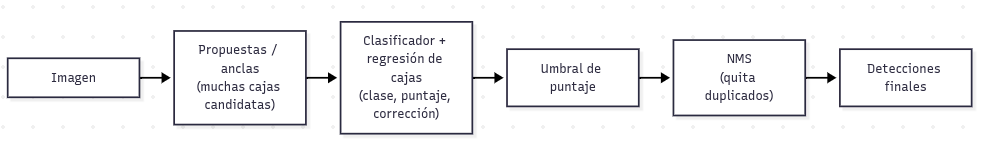

In [ ]:
# ============================================================
# 5. Deteccion: cajas, IoU, NMS y anclas (desde cero)
# ============================================================
rng = np.random.default_rng(11)                           # semilla propia de esta seccion
# Convencion: caja = [x1, y1, x2, y2] (esquina superior izquierda e inferior derecha, en pixeles).
def iou_matriz(a, b):
    """IoU = area(interseccion) / area(union) entre TODAS las parejas de cajas: a (N,4), b (M,4) -> (N,M)."""
    a, b = np.atleast_2d(a).astype(float), np.atleast_2d(b).astype(float)
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)                   # 0 si no se solapan
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (area_a[:, None] + area_b[None, :] - inter)


def nms_np(cajas, puntajes, umbral_iou=0.5):
    """Supresion de no maximos: toma la caja de mayor puntaje, elimina las que se le solapan con IoU > umbral, y repite."""
    orden = np.argsort(-puntajes, kind="stable")
    quedan = []
    while orden.size:
        i = orden[0]; quedan.append(i)
        if orden.size == 1:
            break
        iou = iou_matriz(cajas[i], cajas[orden[1:]])[0]
        orden = orden[1:][iou <= umbral_iou]                                         # sobreviven las que NO se solapan demasiado
    return np.array(quedan, dtype=int)


# --- Verificaciones del IoU: a mano, simetria, casos limite ---
A, B = np.array([0, 0, 10, 10]), np.array([5, 5, 15, 15])
assert np.isclose(iou_matriz(A, B)[0, 0], 25 / 175)                                  # interseccion 5x5=25; union 100+100-25=175
assert np.isclose(iou_matriz(A, A)[0, 0], 1.0) and iou_matriz(A, np.array([20, 20, 30, 30]))[0, 0] == 0.0
cajas_r = rng.uniform(0, 50, (30, 2)); cajas_r = np.hstack([cajas_r, cajas_r + rng.uniform(5, 30, (30, 2))])
M = iou_matriz(cajas_r, cajas_r)
assert np.allclose(M, M.T) and np.allclose(np.diag(M), 1) and (M >= 0).all() and (M <= 1 + 1e-12).all()
print("OK: IoU de [0,0,10,10] y [5,5,15,15] = 25/175 = 0.143; simétrico, diagonal 1, en [0,1].")

# --- Verificaciones de NMS: propiedades y comparacion con torchvision ---
n_coinciden = 0
for ensayo in range(50):
    c = rng.uniform(0, 60, (40, 2)); c = np.hstack([c, c + rng.uniform(10, 30, (40, 2))]); p = rng.uniform(size=40)
    q = nms_np(c, p, 0.5)
    iou_q = iou_matriz(c[q], c[q]); np.fill_diagonal(iou_q, 0)
    assert (iou_q <= 0.5).all()                                                      # propiedad 1: las que quedan no se solapan > umbral entre si
    resto = np.setdiff1d(np.arange(40), q)
    for r_ in resto:                                                                 # propiedad 2: toda caja eliminada solapa > umbral con una conservada de MAYOR puntaje
        assert ((iou_matriz(c[r_], c[q])[0] > 0.5) & (p[q] > p[r_])).any()
    if HAY_TORCHVISION:
        ref = tv_nms(torch.as_tensor(c, dtype=torch.float32), torch.as_tensor(p, dtype=torch.float32), 0.5).numpy()
        assert np.array_equal(q, ref); n_coinciden += 1
print("OK: NMS desde cero cumple las dos propiedades (50 ensayos aleatorios).")
if HAY_TORCHVISION:
    assert np.allclose(iou_matriz(cajas_r, cajas_r), tv_box_iou(torch.as_tensor(cajas_r, dtype=torch.float32), torch.as_tensor(cajas_r, dtype=torch.float32)).numpy(), atol=1e-5)
    print(f"OK: nms_np == torchvision.ops.nms en {n_coinciden}/50 ensayos (mismos índices y mismo orden) e iou_matriz == torchvision.ops.box_iou.")
else:
    print("torchvision no está instalado: se omite la comparación opcional con torchvision.ops (las propiedades de arriba ya validan el algoritmo).")

# --- Ejemplo visual: 3 objetos y muchas detecciones duplicadas ---
gt = np.array([[10, 10, 40, 40], [60, 20, 95, 55], [30, 60, 70, 95]], dtype=float)
det, pun = [], []
for g, base in zip(gt, [0.95, 0.9, 0.85]):
    for _ in range(6):
        det.append(g + rng.normal(0, 3.5, 4)); pun.append(base - rng.uniform(0, 0.25))
det.append(np.array([0, 70, 25, 100.0])); pun.append(0.4)                           # una falsa alarma aislada
det, pun = np.array(det), np.array(pun)
keep = nms_np(det, pun, 0.5)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, cajas, titulo in [(axes[0], det, f"{len(det)} detecciones antes de NMS"), (axes[1], det[keep], f"{len(keep)} tras NMS (umbral IoU 0.5)")]:
    ax.set_xlim(0, 105); ax.set_ylim(105, 0); ax.set_aspect("equal"); ax.set_title(titulo, fontweight="bold", fontsize=10)
    for g in gt:
        ax.add_patch(mpatches.Rectangle(g[:2], g[2] - g[0], g[3] - g[1], fill=False, ec="#16a34a", lw=3))
    for c in cajas:
        ax.add_patch(mpatches.Rectangle(c[:2], c[2] - c[0], c[3] - c[1], fill=False, ec="#dc2626", lw=1.2))
axes[0].plot([], [], color="#16a34a", lw=3, label="verdad (3 objetos)"); axes[0].plot([], [], color="#dc2626", lw=1.2, label="detecciones"); axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()
print(f"NMS conservó {len(keep)} de {len(det)} cajas: 3 duplicados resueltos + 1 falsa alarma aislada (que NMS NO puede eliminar: eso lo decide el puntaje).")
assert len(keep) == 4

# --- Anclas: cajas candidatas a distintas escalas y proporciones, emparejadas por IoU ---
def generar_anclas(lado_mapa, paso, escalas, razones):
    """Cuadricula de centros (cada `paso` pixeles) x escalas x proporciones ancho/alto -> cajas [x1,y1,x2,y2]."""
    centros = (np.arange(lado_mapa) + 0.5) * paso
    anclas = []
    for cy in centros:
        for cx in centros:
            for s in escalas:
                for r in razones:
                    w, h = s * np.sqrt(r), s / np.sqrt(r)                            # area s^2 y proporcion w/h = r
                    anclas.append([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])
    return np.array(anclas)

anclas = generar_anclas(lado_mapa=8, paso=13, escalas=[20, 35, 55], razones=[0.5, 1.0, 2.0])
iou_ag = iou_matriz(anclas, gt)
positivas = (iou_ag.max(1) >= 0.5)
print(f"Anclas: {len(anclas)} (8×8 posiciones × 3 escalas × 3 proporciones). Con IoU ≥ 0.5 respecto a algún objeto: {positivas.sum()} positivas, {(iou_ag.max(1) < 0.3).sum()} claramente negativas (IoU < 0.3).")
print("Mejor ancla para cada objeto (IoU):", np.round(iou_ag.max(0), 2), "→ el detector aprende a CORREGIR esas anclas (regresión de cajas) y a clasificar cada una.")
assert iou_ag.max(0).min() > 0.4 and positivas.sum() > 3

---
**Lectura.** El IoU cumple lo esperado (valor exacto a mano, simetría, rango $[0,1]$), y nuestro NMS **cumple las dos propiedades que lo definen** en 50 ensayos aleatorios y, si `torchvision` está instalado, **coincide exactamente** con `torchvision.ops.nms` (mismos índices y mismo orden) y con `box_iou`. En el ejemplo, 19 cajas se reducen a 4: **los duplicados se resuelven** y la falsa alarma aislada **sobrevive** (NMS no juzga si una caja es correcta, solo si está *repetida*; eso lo decide el puntaje). Con 576 anclas por imagen solo **11** son positivas: el desbalance extremo entre positivas y negativas es una dificultad real del entrenamiento de detectores (por eso existen la función de pérdida *focal* de RetinaNet o el muestreo de negativos duros), y se vincula con los [conjuntos desbalanceados del Módulo 08](../08%20-%20Temas%20Avanzados%20de%20ML/03_Datasets_Desbalanceados.ipynb).

---

## 6. Evaluar un Detector: Precisión, Recobrado, AP y mAP 📏

Para un **umbral de puntaje** dado, cada detección es **verdadero positivo (TP)** si su IoU con una verdad **aún no emparejada** es $\ge$ umbral, y **falso positivo (FP)** en caso contrario (incluidos los **duplicados**); las verdades sin detección son **falsos negativos (FN)**. Entonces

$$\text{precisión}=\frac{TP}{TP+FP},\qquad \text{recobrado}=\frac{TP}{TP+FN}$$

(las mismas definiciones del [Módulo 03](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb), pero con «acierto» definido por la IoU). Variando el umbral de puntaje se obtiene la **curva precisión–recobrado**; el **AP** (*average precision*) es el **área bajo ella** (con la precisión hecha monótona decreciente, interpolación de «todos los puntos» de PASCAL VOC) y el **mAP** es el **promedio del AP sobre las clases**. El *benchmark* COCO promedia además el AP sobre **umbrales de IoU de 0.50 a 0.95**: premia la **localización** precisa, no solo «acertar la zona». El AP **penaliza** tanto los duplicados como los objetos no detectados, y **no depende de un umbral de puntaje particular** (a diferencia de la precisión y el recobrado en un punto de operación).

In [ ]:
# ============================================================
# 6. Precision, recobrado, AP y mAP desde cero
# ============================================================
def ap_clase(detecciones, gts, umbral_iou=0.5):
    """AP de UNA clase. detecciones: lista de (id_imagen, puntaje, caja). gts: dict id_imagen -> array (n,4).
    Recorre las detecciones de mayor a menor puntaje: acierto (TP) si su IoU con una verdad AUN NO usada es >= umbral; si no, falso positivo (FP).
    Devuelve (AP, precision, recobrado), con AP = area bajo la curva precision-recobrado con precision monotona (interpolacion de 'todos los puntos')."""
    n_gt = sum(len(v) for v in gts.values())
    orden = sorted(detecciones, key=lambda d: -d[1])
    usadas = {k: np.zeros(len(v), dtype=bool) for k, v in gts.items()}
    tp = np.zeros(len(orden))
    for i, (img_id, _, caja) in enumerate(orden):
        g = gts.get(img_id, np.zeros((0, 4)))
        if len(g):
            ious = iou_matriz(caja, g)[0]; j = int(np.argmax(ious))
            if ious[j] >= umbral_iou and not usadas[img_id][j]:
                tp[i] = 1; usadas[img_id][j] = True                                  # cada verdad solo puede ser detectada UNA vez
    ctp, cfp = np.cumsum(tp), np.cumsum(1 - tp)
    prec = ctp / (ctp + cfp) if len(orden) else np.array([]); rec = ctp / max(n_gt, 1)
    mrec = np.concatenate([[0], rec, [1]]); mpre = np.concatenate([[0], prec, [0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])                                          # envolvente monotona decreciente
    cambios = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[cambios + 1] - mrec[cambios]) * mpre[cambios + 1])), prec, rec


# --- Verificacion a mano: 3 verdades; detecciones en orden de puntaje: acierto, falso positivo, acierto (la 3.ª verdad no se detecta) ---
gts_demo = {0: np.array([[0, 0, 10, 10], [20, 20, 30, 30], [50, 50, 60, 60]], dtype=float)}
dets_demo = [(0, 0.9, np.array([0, 0, 10, 10.])), (0, 0.8, np.array([80, 80, 90, 90.])), (0, 0.7, np.array([20, 20, 30, 31.]))]
ap_demo, prec_demo, rec_demo = ap_clase(dets_demo, gts_demo)
assert np.allclose(prec_demo, [1, 0.5, 2 / 3]) and np.allclose(rec_demo, [1 / 3, 1 / 3, 2 / 3])
assert np.isclose(ap_demo, 1 / 3 * 1 + 1 / 3 * 2 / 3)                                # 0.5556: area bajo la envolvente
print(f"OK (a mano): precisión {np.round(prec_demo, 3)}, recobrado {np.round(rec_demo, 3)} → AP = 1/3·1 + 1/3·2/3 = {ap_demo:.4f}")

# Un detector perfecto tiene AP = 1; uno que no detecta nada, AP = 0; duplicados sin NMS bajan el AP
ap_perf, _, _ = ap_clase([(0, 0.9 - 0.1 * i, g) for i, g in enumerate(gts_demo[0])], gts_demo)
ap_nada, _, _ = ap_clase([], gts_demo)
ap_dup, _, _ = ap_clase([(0, 0.95, gts_demo[0][0]), (0, 0.94, gts_demo[0][0]), (0, 0.93, gts_demo[0][0]),                       # el mismo objeto 3 veces
                         (0, 0.6, gts_demo[0][1]), (0, 0.5, gts_demo[0][2])], gts_demo)
assert np.isclose(ap_perf, 1.0) and ap_nada == 0.0 and ap_dup < ap_perf
print(f"AP detector perfecto = {ap_perf:.2f} | sin detecciones = {ap_nada:.2f} | con 2 duplicados del mismo objeto = {ap_dup:.3f}  (los duplicados cuentan como falsos positivos).")

# Efecto del umbral de IoU: exigir mas localizacion baja el AP (mAP de COCO promedia IoU de 0.50 a 0.95)
dets_ruido = [(0, 0.9 - 0.1 * i, g + rng.normal(0, 1.2, 4)) for i, g in enumerate(gts_demo[0])]
aps = {u: ap_clase(dets_ruido, gts_demo, u)[0] for u in [0.5, 0.75, 0.9]}
print("AP de un detector con cajas ligeramente desplazadas según el umbral de IoU:", {k: round(v, 2) for k, v in aps.items()})
assert aps[0.5] >= aps[0.75] >= aps[0.9]

---
**Lectura.** El AP del ejemplo a mano coincide con el cálculo $\tfrac13\cdot1+\tfrac13\cdot\tfrac23=0.556$; un detector perfecto da 1 y uno sin detecciones, 0; **los duplicados de un mismo objeto cuentan como falsos positivos** (el AP baja de 1 a ≈ 0.73 con dos duplicados). Y el AP **cae al exigir más localización**: cajas desplazadas apenas ≈ 1 píxel dan AP = 1 con IoU 0.5 pero **casi 0 con IoU 0.9** (el detalle exacto depende de la semilla; el patrón no). Por eso conviene reportar el umbral junto al mAP.

---

## 7. Un Detector de Juguete: Ventana Deslizante + Clasificador + NMS 🧸

Construimos el detector **más simple posible**, el que precede históricamente a R-CNN:

1. **Escenas sintéticas:** lienzos de 64×64 con ruido y fondo suave y **1–3 figuras** (cuadrado, círculo, cruz) de 16×16 sin solaparse. Generarlas por código nos da la **verdad exacta** (cajas y clases), algo que en datos reales cuesta mucho etiquetar. **Son sintéticas**: los resultados serán **más optimistas** que con fotografías reales.
2. **Clasificador de parches:** un MLP sobre ventanas de 16×16 con cuatro clases (fondo + 3 figuras), entrenado con **positivos** (la verdad movida ≤ 2 píxeles) y **negativos** (ventanas con IoU < 0.25 respecto a todas las verdades).
3. **Ventana deslizante:** se puntúan **625 ventanas** por escena (paso 2), se conservan las de probabilidad $>0.5$ y se aplica **NMS por clase**.
4. **Evaluación:** AP por clase y mAP con IoU $\ge 0.5$, con y sin NMS.

> ⚠️ El clasificador se evalúa sobre **escenas nuevas** (semillas distintas de las de entrenamiento). Aun así, el generador es el mismo: es un **laboratorio**, no una garantía de rendimiento en el mundo real.

In [ ]:
# ============================================================
# 7. Detector de juguete: ventana deslizante + clasificador + NMS
# ============================================================
LADO, TAM_OBJ = 64, 16                                          # lienzo 64x64; objetos de 16x16 (en la prueba de escala usaremos 26x26)
CLASES = ["fondo", "cuadrado", "círculo", "cruz"]


def dibujar_figura(clase, tam):
    """Mascara booleana tam×tam de la figura: 1 = cuadrado, 2 = circulo, 3 = cruz."""
    yy, xx = np.mgrid[:tam, :tam]; c = (tam - 1) / 2
    if clase == 1:
        return (np.abs(xx - c) <= tam * 0.42) & (np.abs(yy - c) <= tam * 0.42)
    if clase == 2:
        return (xx - c) ** 2 + (yy - c) ** 2 <= (tam * 0.45) ** 2
    return (np.abs(xx - c) <= tam * 0.14) | (np.abs(yy - c) <= tam * 0.14)


def generar_escena(rng, n_obj=None, tam=TAM_OBJ, sigma=0.12):
    """Lienzo con ruido y un fondo suave; 1-3 figuras sin solaparse. Devuelve (imagen, cajas (n,4), clases (n,))."""
    yy, xx = np.mgrid[:LADO, :LADO]
    img = 0.15 + 0.1 * np.sin(xx / 9 + rng.uniform(0, 6)) * np.cos(yy / 11 + rng.uniform(0, 6)) + rng.normal(0, sigma, (LADO, LADO))
    cajas, clases = [], []
    for _ in range(n_obj or rng.integers(1, 4)):
        for _intento in range(50):
            x, y = rng.integers(0, LADO - tam + 1, 2); c = np.array([x, y, x + tam, y + tam], dtype=float)
            if not cajas or iou_matriz(c, np.array(cajas)).max() == 0:                # sin ningun solape con las ya colocadas
                k = int(rng.integers(1, 4))
                img[y:y + tam, x:x + tam][dibujar_figura(k, tam)] += rng.uniform(0.6, 0.9)
                cajas.append(c); clases.append(k); break
    return img.astype(np.float32), np.array(cajas), np.array(clases)


def extraer_parche(img, x, y, lado=TAM_OBJ):
    return img[y:y + lado, x:x + lado]


# --- Conjunto de entrenamiento de parches: positivos con pequeno desplazamiento, negativos (fondo y solapes parciales) ---
rng_t = np.random.default_rng(7)
P, Y = [], []
for _ in range(500):
    img, cajas, clases = generar_escena(rng_t)
    for c, k in zip(cajas, clases):
        for _ in range(3):                                                           # positivos: caja de la verdad movida hasta ±2 pixeles
            dx, dy = rng_t.integers(-2, 3, 2); x, y = int(np.clip(c[0] + dx, 0, LADO - TAM_OBJ)), int(np.clip(c[1] + dy, 0, LADO - TAM_OBJ))
            P.append(extraer_parche(img, x, y).ravel()); Y.append(k)
    n_neg = 0
    while n_neg < 8:                                                                 # negativos: ventanas con IoU < 0.25 con TODAS las verdades
        x, y = rng_t.integers(0, LADO - TAM_OBJ + 1, 2)
        if iou_matriz(np.array([x, y, x + TAM_OBJ, y + TAM_OBJ]), cajas).max() < 0.25:
            P.append(extraer_parche(img, x, y).ravel()); Y.append(0); n_neg += 1
P, Y = np.array(P), np.array(Y)
print("Parches de entrenamiento:", P.shape, "| por clase:", dict(zip(CLASES, np.bincount(Y))))

t0 = time.time()
clasificador = MLPClassifier((64,), max_iter=300, random_state=0).fit(P, Y)
print(f"Clasificador de parches (MLP 256-64-4) entrenado en {time.time() - t0:.1f} s")
P_te, Y_te = [], []
rng_v = np.random.default_rng(8)
for _ in range(100):
    img, cajas, clases = generar_escena(rng_v)
    c, k = cajas[0], clases[0]; P_te.append(extraer_parche(img, int(c[0]), int(c[1])).ravel()); Y_te.append(k)
    x, y = rng_v.integers(0, LADO - TAM_OBJ + 1, 2)
    if iou_matriz(np.array([x, y, x + TAM_OBJ, y + TAM_OBJ]), cajas).max() < 0.25:
        P_te.append(extraer_parche(img, x, y).ravel()); Y_te.append(0)
print(f"Exactitud del clasificador sobre parches centrados o de fondo (prueba): {clasificador.score(np.array(P_te), np.array(Y_te)):.3f}")


def parches_de(img, pos, lado):
    """Recorta ventanas lado×lado y las lleva a 16×16 (promedio por bloques si la ventana es mayor) para el clasificador."""
    p = np.array([extraer_parche(img, x, y, lado) for x, y in pos], dtype=np.float32)
    if lado != TAM_OBJ:
        p = F.interpolate(torch.as_tensor(p)[:, None], size=(TAM_OBJ, TAM_OBJ), mode="area").numpy()[:, 0]
    return p.reshape(len(pos), -1)


def detectar(img, clasificador, paso=2, umbral=0.5, umbral_nms=0.3, usar_nms=True, lados=(TAM_OBJ,)):
    """Ventana deslizante (una o varias escalas): puntua cada ventana; conserva las de P(objeto) > umbral; NMS por clase."""
    cajas, prob = [], []
    for lado in lados:
        xs = list(range(0, LADO - lado + 1, paso)); pos = [(x, y) for y in xs for x in xs]
        prob.append(clasificador.predict_proba(parches_de(img, pos, lado)))          # (n_ventanas, 4)
        cajas.append(np.array([[x, y, x + lado, y + lado] for x, y in pos], dtype=float))
    cajas, prob = np.vstack(cajas), np.vstack(prob)
    salida = []                                                                      # (clase, puntaje, caja)
    for k in (1, 2, 3):
        m = prob[:, k] > umbral
        if not m.any():
            continue
        cb, pk = cajas[m], prob[m, k]
        sel = nms_np(cb, pk, umbral_nms) if usar_nms else np.arange(len(cb))
        salida += [(k, float(pk[i]), cb[i]) for i in sel]
    return salida, int(len(cajas))


def evaluar_detector(escenas, umbral_iou=0.5, **kw):
    """AP por clase y mAP sobre una lista de escenas (img, cajas, clases). Devuelve (AP por clase, mAP, n. de detecciones, precision y recobrado globales)."""
    por_clase = {k: [] for k in (1, 2, 3)}
    for i, (img, cajas, clases) in enumerate(escenas):
        for k, p, c in detectar(img, clasificador, **kw)[0]:
            por_clase[k].append((i, p, c))
    ap, tp_tot, n_det = {}, 0, 0
    for k in (1, 2, 3):
        gts = {i: esc[1][esc[2] == k] for i, esc in enumerate(escenas)}
        a, prec, rec = ap_clase(por_clase[k], gts, umbral_iou); ap[CLASES[k]] = a
        if len(prec):
            tp_tot += rec[-1] * sum(len(v) for v in gts.values()); n_det += len(prec)
    n_gt = sum(len(e[1]) for e in escenas)
    return ap, float(np.mean(list(ap.values()))), n_det, (tp_tot / max(n_det, 1), tp_tot / n_gt)


rng_e = np.random.default_rng(99)
escenas_test = [generar_escena(rng_e) for _ in range(60)]
n_obj_total = sum(len(e[1]) for e in escenas_test)
t0 = time.time()
ap_con, map_con, n_con, (pr_con, re_con) = evaluar_detector(escenas_test, usar_nms=True)
t_det = (time.time() - t0) / len(escenas_test)
ap_sin, map_sin, n_sin, (pr_sin, re_sin) = evaluar_detector(escenas_test, usar_nms=False)
print(f"{len(escenas_test)} escenas de prueba con {n_obj_total} objetos. Ventanas por escena: {detectar(escenas_test[0][0], clasificador)[1]} ({t_det * 1000:.0f} ms por escena)")
display(pd.DataFrame({"AP@0.5 sin NMS": ap_sin, "AP@0.5 con NMS": ap_con}).T.assign(mAP=[map_sin, map_con]).round(3))
print(f"Detecciones devueltas: sin NMS {n_sin} (precisión global {pr_sin:.2f}) | con NMS {n_con} (precisión global {pr_con:.2f}); objetos reales: {n_obj_total}; recobrado {re_sin:.2f} y {re_con:.2f}.")
assert map_con > map_sin and map_con > 0.5

# --- Visualizacion de una escena: verdad (verde) y detecciones (rojo) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
img, cajas, clases = escenas_test[3]
for ax, usar, titulo in [(axes[0], None, "Verdad (cajas verdes)"), (axes[1], False, "Detecciones SIN NMS"), (axes[2], True, "Detecciones CON NMS")]:
    ax.imshow(img, cmap="gray", vmin=0, vmax=1.1); ax.set_title(titulo, fontweight="bold", fontsize=10); ax.axis("off")
    for c, k in zip(cajas, clases):
        ax.add_patch(mpatches.Rectangle(c[:2], 16, 16, fill=False, ec="#16a34a", lw=2.5)); 
        if usar is None:
            ax.text(c[0], c[1] - 1, CLASES[k], color="#16a34a", fontsize=8, fontweight="bold")
    if usar is not None:
        for k, p, c in detectar(img, clasificador, usar_nms=usar)[0]:
            ax.add_patch(mpatches.Rectangle(c[:2], 16, 16, fill=False, ec="#dc2626", lw=1))
            if usar:
                ax.text(c[0], c[3] + 4, f"{CLASES[k][:3]} {p:.2f}", color="#dc2626", fontsize=6)
plt.tight_layout(); plt.show()

# --- Limites: la ESCALA. Objetos de 16x16 (entrenamiento), de 20x20 y de 26x26, con una ventana fija y con ventanas de varios tamanos ---
rng_g = np.random.default_rng(5)
filas = []
for tam in [16, 20, 26]:
    esc = [generar_escena(rng_g, n_obj=2, tam=tam) for _ in range(40)]
    for nombre, lados in [("una escala (16)", (16,)), ("tres escalas (16, 20, 26)", (16, 20, 26))]:
        _, m, n_d, _ = evaluar_detector(esc, lados=lados)
        filas.append({"tamaño del objeto": f"{tam}×{tam}", "ventanas": nombre, "mAP@0.5": round(m, 3), "detecciones": n_d})
tabla_escala = pd.DataFrame(filas).pivot(index="ventanas", columns="tamaño del objeto", values="mAP@0.5")
display(tabla_escala)
assert tabla_escala.loc["una escala (16)", "26×26"] < 0.2 and tabla_escala.loc["tres escalas (16, 20, 26)", "26×26"] > tabla_escala.loc["una escala (16)", "26×26"] + 0.3
print("Con una sola escala, un objeto de 26×26 NO se puede detectar a IoU ≥ 0.5 (una ventana de 16×16 cubre como mucho 256/676 = 38 % de él); usar varias escalas lo arregla, a costa de más ventanas.")
print("Otros límites: el costo crece con ventanas × clasificador; los objetos solapados compiten en NMS; el clasificador no ve el contexto. Eso resuelven R-CNN, SSD o YOLO: comparten el cómputo convolucional de toda la imagen.")

---
**Lectura honesta del detector de juguete.** Con **NMS** el mAP@0.5 es ≈ 0.98; **sin NMS** cae a ≈ 0.58: el clasificador reacciona a **todas las ventanas vecinas** de cada figura (se entrenó con desplazamientos de hasta 2 píxeles) y las ≈ 2 000 detecciones incluyen muchísimos duplicados que cuentan como falsos positivos. Pero observa el matiz: aun con NMS, la **precisión global** a un umbral de 0.5 es solo ≈ 0.3 (421 detecciones para 119 objetos): sobreviven **falsas alarmas de fondo con puntaje moderado** que **no** dañan el AP porque quedan al **final** del *ranking*; en un sistema real habría que **subir el umbral** (menos recobrado, más precisión). El AP y el punto de operación son cosas distintas. Y la **escala** es el límite más claro: con **una sola ventana de 16×16**, el mAP baja a ≈ 0.65 con objetos de 20×20 y a **0** con objetos de 26×26 (una ventana de 16×16 cubre como máximo el 38 % de un objeto de 26×26: **nunca** alcanza IoU 0.5, por muy bueno que sea el clasificador); con **tres escalas** se recupera (≈ 0.93 y ≈ 0.79), a costa de **más ventanas**. R-CNN, SSD y YOLO resuelven justo esto: **comparten el cálculo convolucional de toda la imagen**, predicen cajas con **anclas multiescala** y entrenan clasificador y regresión de cajas **conjuntamente**.

---

## 8. De la Ventana Deslizante a R-CNN, SSD y YOLO; y un Detector Preentrenado (Opcional) 🌐

| Familia | Idea clave | Compromiso |
|---|---|---|
| **R-CNN** (Girshick et al., 2014) | ≈ 2 000 **propuestas** de región (*selective search*), cada una recortada y clasificada por una CNN | Preciso pero **lentísimo** (una CNN por propuesta) |
| **Fast / Faster R-CNN** (2015) | **Una** pasada CNN por imagen; *RoI pooling*; en Faster, una **red de propuestas (RPN)** con **anclas** | **Dos etapas**: más precisión, más latencia |
| **YOLO** (Redmon et al., 2016) | Divide la imagen en una **cuadrícula** y predice cajas y clases **en una sola pasada** | **Una etapa**: muy rápido, histórica­mente menos preciso con objetos pequeños |
| **SSD** (Liu et al., 2016) | Cajas por defecto (anclas) en **mapas de varias resoluciones** | Buen equilibrio velocidad/precisión |
| **DETR** (Carion et al., 2020) | **Transformer** que predice un *conjunto* de cajas; sin anclas ni NMS | Entrenamiento más lento *(ver Géron, Cap. 16)* |

En la práctica **no se entrena un detector desde cero**: se parte de un modelo **preentrenado** (COCO/ImageNet) y se hace *fine-tuning*, exactamente como en el [Módulo 08](../08%20-%20Temas%20Avanzados%20de%20ML/01_Transfer_Learning_y_Fine_Tuning.ipynb) (backbone preentrenado + cabeza nueva, con tasa diferencial). La celda siguiente carga un **Faster R-CNN con *backbone* MobileNetV3** de `torchvision` y lo aplica a la foto de ejemplo.

> ⚠️ **Este bloque NO se ejecuta por defecto** (`USAR_DETECTOR_PRETRAINED = False` en la primera celda): necesita `torchvision` y **conexión a internet** para bajar los pesos (en Google Colab funciona directamente). Está protegido con `try/except`: sin red, imprime un aviso y el cuaderno **sigue** sin errores. Los nombres de modelo y de pesos pueden cambiar entre versiones de `torchvision`.

In [ ]:
# ============================================================
# 8. (OPCIONAL, requiere red) Detector preentrenado de torchvision sobre las fotos de ejemplo
# ============================================================
if USAR_DETECTOR_PRETRAINED:
    try:
        import torchvision
        from torchvision.models import detection as tv_det
        t0 = time.time()
        pesos = tv_det.FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT        # pesos entrenados en COCO (descarga de decenas de MB la primera vez)
        modelo = tv_det.fasterrcnn_mobilenet_v3_large_320_fpn(weights=pesos, box_score_thresh=0.5)
        modelo.eval()
        categorias = pesos.meta["categories"]                                        # nombres de las 91 categorias de COCO
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
        for ax, nombre in zip(axes, ["china.jpg", "flower.jpg"]):
            img = load_sample_image(nombre)
            entrada = torch.as_tensor(img.transpose(2, 0, 1).astype(np.float32) / 255.0)   # (3, H, W) en [0, 1]; el modelo normaliza y redimensiona por dentro
            with torch.no_grad():
                salida = modelo([entrada])[0]                                        # dict con 'boxes', 'labels' y 'scores' (ya incluye NMS)
            ax.imshow(img); ax.axis("off")
            print(f"{nombre}: {len(salida['boxes'])} detecciones con puntaje > 0.5")
            for caja, etiqueta, punt in zip(salida["boxes"].numpy(), salida["labels"].numpy(), salida["scores"].numpy()):
                ax.add_patch(mpatches.Rectangle(caja[:2], caja[2] - caja[0], caja[3] - caja[1], fill=False, ec="#dc2626", lw=2))
                ax.text(caja[0], caja[1] - 3, f"{categorias[etiqueta]} {punt:.2f}", color="white", fontsize=8, bbox=dict(facecolor="#dc2626", pad=1, lw=0))
                print(f"   {categorias[etiqueta]:<14} puntaje {punt:.2f}  caja {np.round(caja, 0)}")
            ax.set_title(f"{nombre}: {len(salida['boxes'])} detecciones", fontweight="bold", fontsize=10)
            if len(salida["boxes"]):                                                 # nuestro NMS sobre las mismas cajas no deberia quitar nada (el modelo ya lo aplico)
                q = nms_np(salida["boxes"].numpy().astype(float), salida["scores"].numpy().astype(float), 0.5)
                print(f"   Nuestro NMS (umbral 0.5) conserva {len(q)} de {len(salida['boxes'])} cajas.")
        plt.tight_layout(); plt.show()
        print(f"[{time.time() - t0:.1f} s] Ojo: COCO tiene 80 categorías de objetos cotidianos («vocabulario cerrado»): lo que no está en la lista se ignora o se confunde con algo parecido.")
    except Exception as e:                                                          # sin red, sin torchvision o error de descarga
        print(f"No se pudo ejecutar la sección opcional ({type(e).__name__}: {str(e)[:150]}). Es normal sin conexión: el resto del cuaderno no depende de ella.")
else:
    print("Sección opcional desactivada (USAR_DETECTOR_PRETRAINED = False). Ponla en True en la primera celda si tienes red (por ejemplo en Google Colab).")

---
**Nota sobre la sección opcional.** Al ejecutarla con red una vez para verificar el código (`USAR_DETECTOR_PRETRAINED = True`; pesos de COCO de ≈ 74 MB): en `china.jpg` (una fotografía de un edificio, sin objetos de COCO) **no hubo detecciones** con puntaje > 0.5; en `flower.jpg` detectó una «**orange**» con puntaje **0.98**: es una **flor** mal nombrada, porque COCO **no tiene** la categoría «flor» (vocabulario cerrado) y el detector la fuerza hacia la categoría más parecida **con mucha confianza**. Un puntaje alto **no** garantiza que la etiqueta sea correcta, y el modelo solo conoce lo que vio al entrenar. Tus cifras pueden variar ligeramente según la versión de `torchvision`.

---

## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Imagen = tensor** | `(H, W)`, `(H, W, C)` en NumPy y **`(N, C, H, W)`** en PyTorch; aplanar pierde la vecindad espacial |
| **Convolución** | Correlación cruzada: kernel deslizante, suma de productos. Tamaño de salida $\lfloor (n+2p-k)/s\rfloor+1$; **verificada** contra `scipy.signal.correlate2d` y `torch.nn.functional.conv2d`. Pesos **compartidos** (448 parámetros frente a > 800 millones de la capa densa equivalente) y **equivarianza** a la traslación |
| **Filtros y *pooling*** | Sobel/gaussiano/laplaciano son **kernels diseñados a mano**; la CNN los **aprende**. El *max-pooling* da invarianza **local** (correlación de mapas ante un desplazamiento de 1 píxel: 0.77 → 0.98) |
| **Clasificar dígitos** | Con imágenes limpias y centradas, **CNN ≈ regresión logística ≈ MLP (≈ 0.97)**; los rasgos HOG-lite a mano quedan abajo (≈ 0.91). La CNN **no es invariante por sí sola**: ante desplazamientos cae a ≈ 0.45, y el **aumento** de datos la lleva a ≈ 0.92; con 100 imágenes el aumento **perjudica** en la prueba normal |
| **IoU y NMS** | IoU = intersección/unión; NMS conserva la caja de mayor puntaje y elimina las de IoU $>\tau$. **Idéntico a `torchvision.ops.nms`** (50/50 ensayos) |
| **AP y mAP** | Área bajo la curva precisión–recobrado (duplicados = FP); mAP = promedio por clase; COCO promedia varios umbrales de IoU. Un buen AP **no implica** buena precisión en un punto de operación |
| **Detector de juguete** | Ventana deslizante + clasificador + NMS: mAP@0.5 ≈ 0.98 **con** NMS y ≈ 0.58 **sin** él (sintético, optimista); falla con **otra escala** (mAP 0 con 26×26 y una ventana fija) |
| **Detectores reales** | R-CNN → Fast/Faster R-CNN (RPN, anclas) → YOLO/SSD (una etapa) → DETR (transformer); se usan **preentrenados** y con *fine-tuning* (Módulo 08) |

> 🎓 **Siguiente paso:** de las imágenes pasamos al texto: el [cuaderno 02](02_Procesamiento_de_Lenguaje_Natural.ipynb) construye TF-IDF, Naive Bayes y LSA desde cero para clasificar y analizar el sentimiento de textos (sección 3.10).

---
##### 🛠️ Práctica 2: Tu propio filtro de bordes y el costo de una capa convolucional

Con la convolución `filtrar` (padding automático), `signal` (`scipy.signal`), `pool2d_np`, `tam_salida` y la foto en grises `gris`:

1. Define `DIAG`, una variante del filtro de Sobel girada 45°: `[[0, 1, 2], [-1, 0, 1], [-2, -1, 0]]` (de tipo `float`), y calcula `resp_diag = filtrar(gris, DIAG)`.
2. Verifica con `assert np.allclose(...)` que `resp_diag` coincide con `signal.correlate2d(gris, DIAG, mode="same")` (un relleno de ceros de 1 píxel equivale al modo `"same"` con un kernel 3×3).
3. Aplica *max-pooling* 2×2 al valor absoluto de la respuesta con `pool2d_np` y guárdalo en `mapa_pool`; comprueba que su forma es la mitad (división entera) de la de `gris`.
4. Cuenta los parámetros de una capa convolucional con 3 canales de entrada, 6 filtros de 5×5 y un sesgo por filtro: `n_params` con la fórmula $F\,(C\,k_h k_w+1)$, y compara con `sum(p.numel() for p in nn.Conv2d(3, 6, 5).parameters())`. Comprueba además con `tam_salida` que con `padding=2` y `stride=1` una entrada de 64 píxeles mantiene su tamaño.

In [ ]:
# Escribe tu código aquí

# DIAG = np.array([[0, 1, 2], [-1, 0, 1], [-2, -1, 0]], dtype=float)
# resp_diag = filtrar(gris, DIAG)
# assert np.allclose(resp_diag, signal.correlate2d(gris, DIAG, mode="same"))
#
# mapa_pool = pool2d_np(np.abs(resp_diag), 2, "max")
#
# n_params = ...          # F * (C * kh * kw + 1)
# n_torch = sum(p.numel() for p in nn.Conv2d(3, 6, 5).parameters())


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
DIAG = np.array([[0, 1, 2], [-1, 0, 1], [-2, -1, 0]], dtype=float)           # Sobel girado 45 grados
resp_diag = filtrar(gris, DIAG)
assert np.allclose(resp_diag, signal.correlate2d(gris, DIAG, mode="same"))   # padding de 1 píxel con kernel 3x3 == modo 'same'

mapa_pool = pool2d_np(np.abs(resp_diag), 2, "max")                           # el pooling reduce el mapa 4 veces (2x2 -> 1 valor)
assert mapa_pool.shape == (gris.shape[0] // 2, gris.shape[1] // 2)
print("Respuesta diagonal:", resp_diag.shape, "-> tras max-pooling 2x2:", mapa_pool.shape)

n_params = 6 * (3 * 5 * 5 + 1)                                               # F * (C * kh * kw + 1)
n_torch = sum(p.numel() for p in nn.Conv2d(3, 6, 5).parameters())
assert n_params == n_torch == 456
assert tam_salida(64, 5, p=2, s=1) == 64
print(f"Parámetros de la capa: {n_params} (PyTorch: {n_torch}); no dependen del tamaño de la imagen. Con padding=2 y stride=1 la salida conserva los 64 píxeles.")
```
</details>

---


---
##### 🛠️ Práctica 3: ¿Qué umbral de NMS conviene?

NMS depende del umbral $\tau$: con uno alto quedan **duplicados** y con uno bajo se pueden **fusionar objetos distintos**. Con las cajas de la Sección 5 (`det` y sus puntajes `pun`, más las verdaderas `gt`), `nms_np` y `ap_clase`:

1. Para cada $\tau$ en `[0.1, 0.3, 0.5, 0.7, 0.9]` aplica `nms_np(det, pun, tau)` y cuenta cuántas cajas se conservan.
2. Calcula el AP@0.5 de las cajas conservadas con `ap_clase`: las detecciones se pasan como una lista de tuplas `(0, puntaje, caja)` y las verdades como `{0: gt}`; la función devuelve `(AP, precisión, recobrado)`.
3. Reúne los resultados en un `DataFrame` llamado `barrido_tau` (índice = $\tau$; columnas `cajas` y `AP`) e imprímelo.
4. Verifica con `assert` que con $\tau=0.5$ se conservan 4 cajas, que con $\tau=0.9$ se conservan **más** que con 0.5 y que el AP con 0.5 es **mayor** que con 0.9. Comenta: ¿por qué bajan el AP los duplicados?

In [ ]:
# Escribe tu código aquí

# filas = {}
# for tau in [0.1, 0.3, 0.5, 0.7, 0.9]:
#     keep_tau = nms_np(det, pun, tau)
#     dets_tau = [(0, pun[i], det[i]) for i in keep_tau]
#     ap_tau, _, _ = ap_clase(dets_tau, {0: gt})
#     filas[tau] = {"cajas": len(keep_tau), "AP": ap_tau}
# barrido_tau = pd.DataFrame(filas).T


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
filas = {}
for tau in [0.1, 0.3, 0.5, 0.7, 0.9]:
    keep_tau = nms_np(det, pun, tau)                                      # índices de las cajas que sobreviven
    dets_tau = [(0, pun[i], det[i]) for i in keep_tau]                    # (imagen, puntaje, caja)
    ap_tau, _, _ = ap_clase(dets_tau, {0: gt})                            # AP@0.5 contra las 3 verdades
    filas[tau] = {"cajas": len(keep_tau), "AP": ap_tau}

barrido_tau = pd.DataFrame(filas).T
barrido_tau.index.name = "tau"
print(barrido_tau.round(3))

assert barrido_tau.loc[0.5, "cajas"] == 4
assert barrido_tau.loc[0.9, "cajas"] > barrido_tau.loc[0.5, "cajas"]
assert barrido_tau.loc[0.5, "AP"] > barrido_tau.loc[0.9, "AP"]
print("Con τ alto sobreviven duplicados del mismo objeto: cuentan como falsos positivos y bajan el AP; con τ=0.5 quedan los 3 objetos y la falsa alarma aislada.")
```
</details>

---


---
### 🧠 Autoevaluación

1. Una capa convolucional 3×3 con 32 filtros recibe imágenes de 3 canales. ¿Cuántos parámetros tiene? Si la imagen pasa de 64×64 a 640×640, ¿cambia ese número? ¿Qué cambia? Explica la diferencia con una capa densa.
2. En el experimento de los dígitos, la CNN sin aumento no fue mejor que la regresión logística en la prueba normal y cayó a ≈ 0.45 en la prueba desplazada. ¿Por qué la **equivarianza** de la convolución no basta para tener **invarianza**? ¿Qué componente de la red rompe la invarianza y qué harías para obtenerla?
3. Un detector tiene mAP@0.5 = 0.95 pero, con el umbral de puntaje que usas en producción, el 70 % de sus alertas son falsas. ¿Cómo es posible? ¿Qué cambiarías y qué métrica reportarías al cliente?
4. ¿Qué ocurre con NMS si dos objetos reales de la misma clase están muy pegados (IoU entre sus cajas ≈ 0.6) y usas $\tau=0.5$? ¿Y si usas $\tau=0.8$? Propón cómo elegir $\tau$ con datos.
5. Diseña cómo adaptarías el detector de juguete para que funcione con objetos de tamaño variable sin recorrer todas las ventanas de todos los tamaños. ¿Qué idea de Faster R-CNN, SSD o YOLO lo resuelve?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>